# BULC-D Early Detection — North Cascades National Park

**Early Detection** is a monitoring workflow built on **BULC-D**, a Bayesian method that uses satellite imagery to flag where the landscape departs from its expected condition: vegetation loss (harvest, fire, insects, windthrow, flooding, clearing) and vegetation gain (regrowth, recovery). It detects *spectral* change; it doesn't say what caused it.

This notebook is a **demonstration and reference workflow** for **North Cascades National Park** (Washington), 2026 season:

1. **What BULC-D / Early Detection is.** How a change is detected.
2. **Setup and important parameters.** The settings, in plain terms.
3. **Case study results.** The products and what they mean.
4. **Understanding parameter behavior.** What happens when one setting moves.
5. **Try it on your own area.**

*These notebooks are the current demonstration workflow. The longer-term goal is an interactive interface: choose an area → configure monitoring → run and view results → inspect detections → click a pixel to see its history. Because intended users may not be able to install local software, Google Earth Engine is the current likely home for that interface; that direction isn't final.*

*Results are precomputed where possible, so running the notebook takes a few minutes. Nothing here has been field-checked.*

In [1]:
import dataclasses
import json
from pathlib import Path
from pprint import pprint

import ee
ee.Initialize(project="bulcd-python-rebuild")

from IPython.display import Markdown, display

from bulcd_early_detection import compare, drawing, outputs, pixel, render, report
from bulcd_early_detection.config import MonitoringControls, build_config, config_summary

OUT = Path("output")

## 1. What is BULC-D / Early Detection?

For every 30 m pixel, BULC-D asks: *compared with how this place normally looks at this time of year, is it different now?*

1. **Expectation (the baseline).** From several years of imagery, BULC-D learns each pixel's normal seasonal pattern of a vegetation index (NBR, sensitive to green vegetation, moisture and burning). It also learns how much that pixel normally varies.
2. **New observations.** Each clear satellite image in the monitoring season (June–September here; Landsat 8/9 and Sentinel-2) is compared with that expectation.
3. **Departure from expectation.** The difference, scaled by the pixel's normal variability, is a z-score: near 0 is normal, strongly negative is "much less vegetation than usual", strongly positive "more".
4. **Bayesian evidence accumulation.** Each observation's departure counts as evidence for *decrease*, *unchanged* or *increase*: weak for a small departure, strong for an extreme one. Starting from even odds, BULC-D updates the three probabilities with every observation. One odd image (cloud edge, shadow) can't flip the answer; a consistent run of evidence does.
5. **Detection decision.** When the probability of decrease (or increase) passes the **decision threshold** (0.5), the pixel is flagged. The date it first passed is the **first-detected date**.

**Two terms used throughout:**
- **Condition relative to expectation:** the state at the end of a monitoring season. *Decrease in 2026* means the landscape is below its expected condition **during 2026**. It does **not** by itself mean the disturbance happened in 2026: something cleared in 2025 and still bare stays "decrease".
- **First detected:** when BULC-D's evidence first crossed the threshold. It is *detection timing*, not an independently verified disturbance date.

### BULC-D and what Early Detection adds

The Bayesian method itself is BULC-D's, unchanged. Early Detection builds a monitoring workflow, products and diagnostics around it.

| | |
|---|---|
| **Core BULC-D** (the legacy Google Earth Engine method, reimplemented in Python) | Seasonal expectation learned from baseline years; departures as z-scores; the evidence table (transition matrix); Bayesian updating with levelers; per-pixel probabilities of decrease / unchanged / increase; the rule for when a change is first detected (first threshold crossing) |
| **Early Detection additions** (this project) | A notebook workflow with plain-language settings on top of the full configuration; precomputed study-area results with area summaries; clearer product framing ("condition relative to expectation", "first detected"); a first-detected-season map built from independent annual runs against a fixed baseline, keeping the within-season date; reference imagery (same-date multi-year panels, a temporal NBR composite); pixel-history charts; one-at-a-time parameter sensitivity maps and charts; study areas from a drawn polygon or an Earth Engine FeatureCollection |

## 2. Setup and important parameters

**Everyday settings** (below): what a user would normally choose.

| Setting | What it controls | Default |
|---|---|---|
| **Monitoring season** | The year and window checked for change | Jun 1 – Sep 30, 2026 |
| **Baseline years** | The years used to learn "normal", same seasonal window each year | 2018–2025 |
| **Decision threshold** | How sure BULC-D must be before flagging a change | 0.5 |
| **Sensitivity** | Scales every departure from normal before it's scored; higher flags smaller departures | 1.0 |

**Advanced settings** (in `advanced()` below): normally left alone.

| Setting | What it controls | Default |
|---|---|---|
| Evidence table (transition matrix) | How strongly each size of departure counts as evidence | the legacy app's default |
| Dampening | How much weight each single observation carries (1 = full) | 0.5 |
| Posterior leveler | After each update, pulls the probabilities slightly back toward even odds (1 = off) | 1.0 (off) |
| Sensors | Satellites used | baseline Landsat 8; monitoring Landsat 8, Landsat 9, Sentinel-2 |
| Masks | Areas not analyzed | water; non-forest land |

Section 4 shows what four of these do when moved one at a time.

In [2]:
controls = MonitoringControls(
    monitoring_year=2026,       # the season checked for change
    season_start="06-01",       # MM-DD; the same window is used in every baseline year
    season_end="09-30",
    baseline_first_year=2018,   # "normal" is learned from these years (inclusive)
    baseline_last_year=2025,
    decision_threshold=0.5,     # flag a change only where its probability exceeds this (0.5-0.99)
    sensitivity=1.0,            # >1 flags smaller departures from normal
)

### Advanced settings

The everyday settings become a complete BULC-D configuration. Any advanced setting can be changed in `advanced()`; the change applies everywhere below.

In [3]:
def advanced(config):
    # Edit any BULC-D setting here; it applies everywhere below. Examples:
    # config.bulc_advanced_params.posterior_leveler = 0.9
    # config.evidence.target.sensors["S2"].enabled = False
    # config.study_area.mask_non_forest = False
    return config


def build(controls, **aoi):
    return advanced(build_config(controls, **aoi))


SHOW_FULL_CONFIG = False   # True prints every BULC-D setting for this run (section 3)

### How this run compares with the legacy app

This Python version matches the legacy Google Earth Engine app's evidence table and method; that combination reproduced a legacy map with 97.9% agreement. Known differences in these runs:

- **Levelers:** the legacy app uses a dampening of 0.7, a posterior leveler of 0.9 and an initial leveler of 0.7. These runs use 0.5, off and off.
- **Baseline sensors:** Landsat 8 only (a Landsat + Sentinel-2 baseline exceeded an Earth Engine memory limit), while monitoring also uses Landsat 9 and Sentinel-2. Tests suggest this mismatch causes some spurious early-June detections; it is being investigated.
- **Masks:** water from JRC Global Surface Water; forest from Hansen tree cover in 2000. The forest mask is a setting, not a BULC-D requirement (the legacy app has none).

## 3. Case study results

**Study area:** North Cascades National Park (2,022 km², two units): the World Database on Protected Areas boundary, excluding Ross Lake and Lake Chelan National Recreation Areas. The results are computed in advance with the settings above, and the notebook checks that they match.

In [4]:
AREA = outputs.north_cascades()
PRECOMPUTED_FOLDER = "projects/bulcd-python-rebuild/assets/north_cascades"
PRECOMPUTED_RUN = "noca_2026_v1"

area_config = build(controls, **AREA.aoi)
results, run_meta = outputs.load_precomputed(PRECOMPUTED_FOLDER, PRECOMPUTED_RUN)
expected = outputs.run_metadata(controls, area_config)
if not all(json.loads(m["controls_json"]) == json.loads(expected["controls_json"])
           and json.loads(m["config_json"]) == json.loads(expected["config_json"]) for m in run_meta):
    print("WARNING: the settings differ from the precomputed run; the maps show the PRECOMPUTED settings. "
          "See the appendix to regenerate.")

print(f"Study area: {outputs.aoi_size_report(AREA)['area_km2']:,.1f} km²")
display(Markdown("**Settings for this run**\n\n| Setting | Value |\n|---|---|\n"
                 + "\n".join(f"| {k} | {v} |" for k, v in config_summary(area_config))))
if SHOW_FULL_CONFIG:
    pprint(dataclasses.asdict(area_config), width=110, compact=True)

token = render.auth_token()
frame, bbox = report.frame_for(AREA.geometry, pad_m=500)
season = report.season_label(controls)
out_dir = OUT / "north_cascades_2026"
INSPECT_PIXEL = (-121.19198, 48.83181)   # (lon, lat) of the pixel inspected below; cyan ring on the maps
PIXEL_SEASONS = [2026]
PIXEL_BASELINE = {}
focus = drawing.study_area("noca_comparison_box")
FOCUS_NAME = "North Cascades comparison area"
focus_frame, focus_bbox = report.frame_for(focus.geometry, pad_m=100)

Study area: 2,022.2 km²


**Settings for this run**

| Setting | Value |
|---|---|
| Baseline (expectation) | 2018–2025, Jun 1 – Sep 30 (Landsat 8) |
| Monitoring season | 2026, Jun 1 – Sep 30 (Landsat 8, Landsat 9, Sentinel-2) |
| Vegetation index | NBR |
| Seasonal model | average level + one annual cycle |
| Sensitivity | 1.0 |
| Evidence table | legacy app's default |
| Dampening | 0.5 |
| Posterior leveler | 1.0 (off) |
| Starting odds | even |
| Recency weighting | off |
| Not analyzed | water, non-forest land |

### 2026 condition relative to expectation

**Where the landscape is below (red), within (gray) or above (blue) its expected condition during the 2026 season**, compared with its 2018–2025 normal. Red does **not** by itself mean the disturbance happened in 2026. Lighter gray is land that isn't analyzed (non-forest); pale blue is water.

*Flagged pixels (decrease or increase) are drawn slightly enlarged on park-wide maps so small patches stay visible. Area totals use the exact 30 m pixels.*

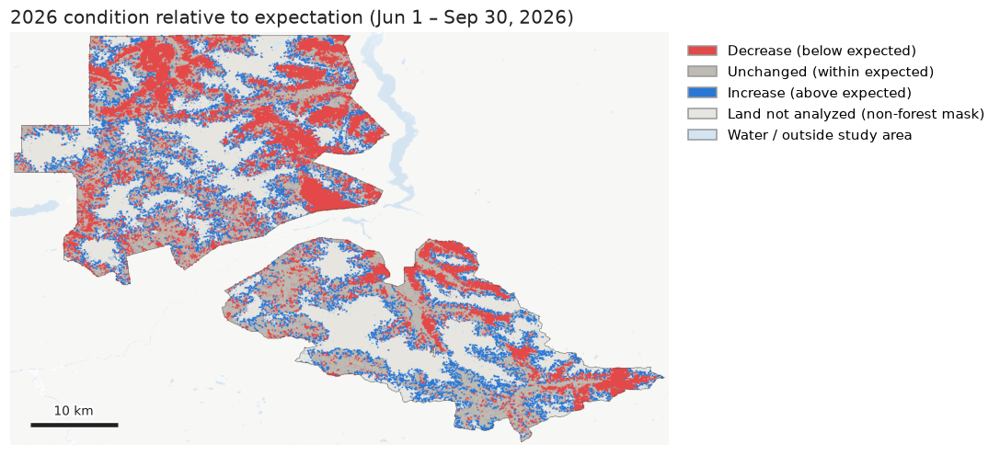

| Outcome | Area (km²) | Share of analyzed land |
|---|---:|---:|
| Decrease (below expected) | 375.76 | 31.6% |
| Unchanged (within expected) | 783.57 | 65.9% |
| Increase (above expected) | 29.97 | 2.5% |
| Land not analyzed (non-forest mask) | 832.86 | — |

In [5]:
report.outcome_map(results, AREA, frame, bbox, f"2026 condition relative to expectation ({season})", token,
                   save_to=out_dir / "condition_2026.png", enlarge_changes=True)
display(Markdown(report.area_table(results, AREA.geometry)[0]))

**Confidence:** the final probability of each flagged decrease or increase (darker is more certain). Only flagged pixels are colored.

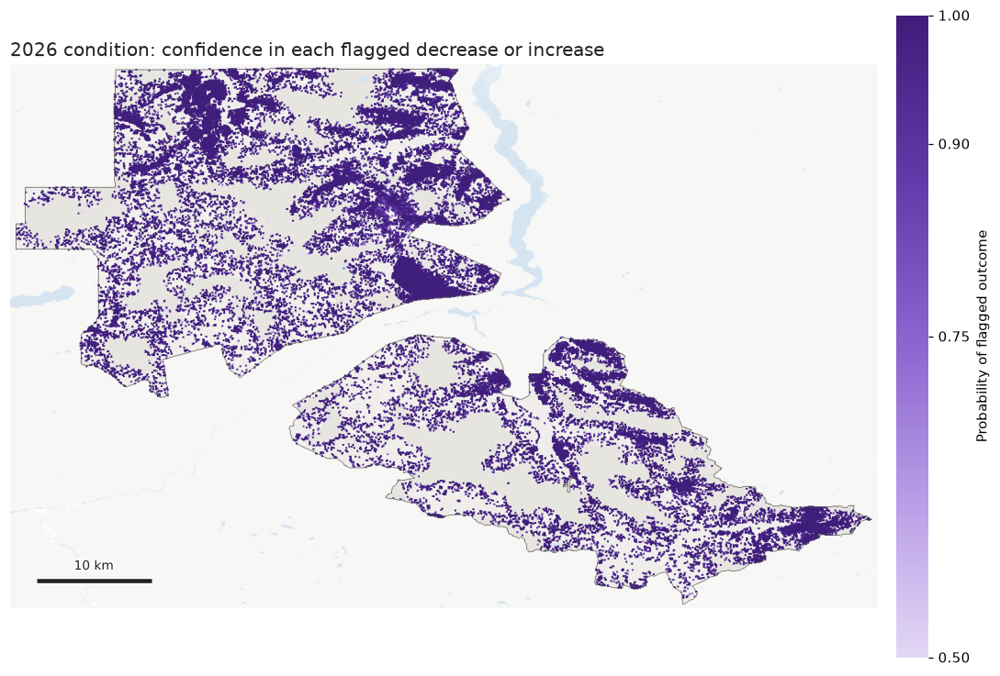

In [6]:
report.confidence_map(results, AREA, frame, bbox, "2026 condition: confidence in each flagged decrease or increase", token,
                      controls.decision_threshold, save_to=out_dir / "confidence.png", enlarge_changes=True);

### First detected within the 2026 season

The date in 2026 when each flagged pixel's probability **first crossed** the threshold. A departure that begins during the season is usually detected a few weeks later. A pixel flagged **in the first days of the season** was most likely already different from normal when monitoring began. Neither is a verified disturbance date.

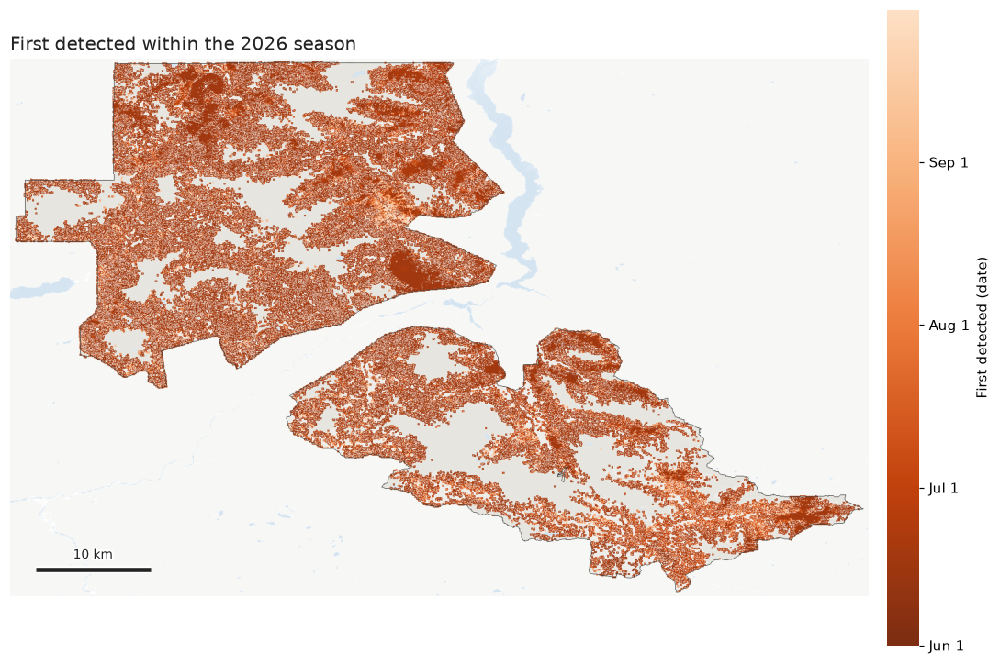

Flagged decrease and increase: 405.73 km², of which 1% first crossed the threshold in the first two weeks of the season.


In [7]:
report.timing_map(results, AREA, frame, bbox, "First detected within the 2026 season", token, controls,
                  save_to=out_dir / "first_detected_2026.png", enlarge_changes=True)
timing = outputs.early_detection_share(results, AREA.geometry, controls.first_doy)
print(f"Flagged decrease and increase: {timing['changed_km2']:.2f} km², of which {100 * timing['early_share']:.0f}% "
      "first crossed the threshold in the first two weeks of the season.")

### Satellite imagery: before and after

Sentinel-2 false color (shortwave infrared / near infrared / red), independent of BULC-D: healthy forest green, bare or damaged ground orange-brown to magenta, snow and ice cyan. Both images are **September 5–30** composites (last baseline year, then this year). Late July–August 2026 imagery here is heavily hazed, so only September is used.

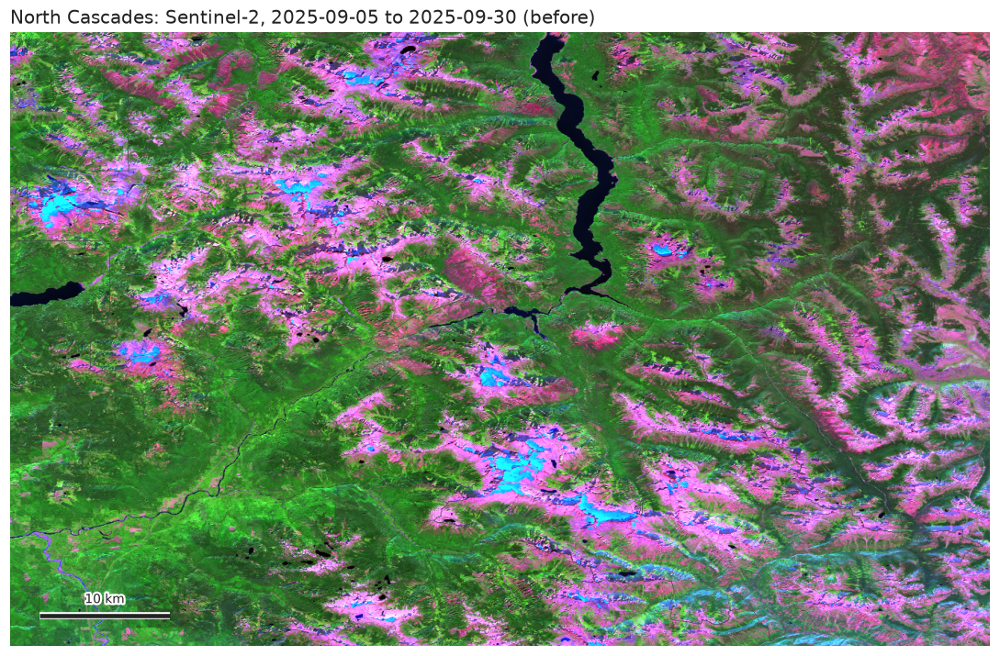

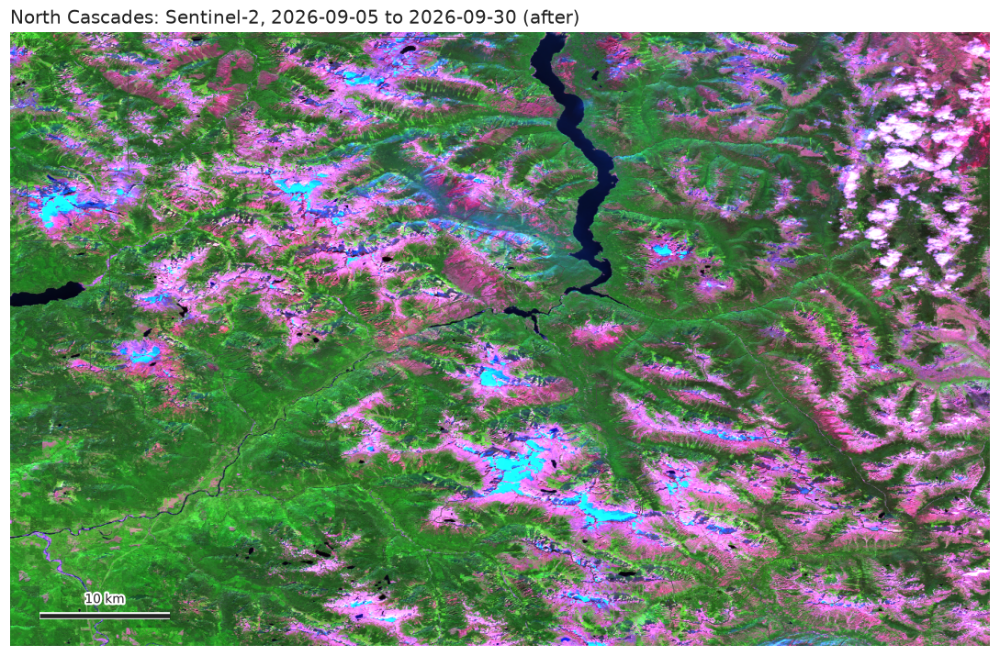

In [8]:
report.reference_pair(AREA, frame, bbox, "North Cascades", token, controls, out_dir, window=("09-05", "09-30"));

### Close-up: North Cascades comparison area

At park scale a 30 m pixel is smaller than a screen pixel, so here is one 5 km box at true resolution (23 km², north unit, 48.83° N 121.19° W). It holds the park's largest patch of 2026 vegetation loss visible in independent imagery. Because seasonal composites are hazed here, the reference uses **single clear dates**: the same time last year, the last clear date before the change, and a clear date after it. The change appears between July 15 and 20, 2026; its cause is not confirmed. The same extent is used in section 4.

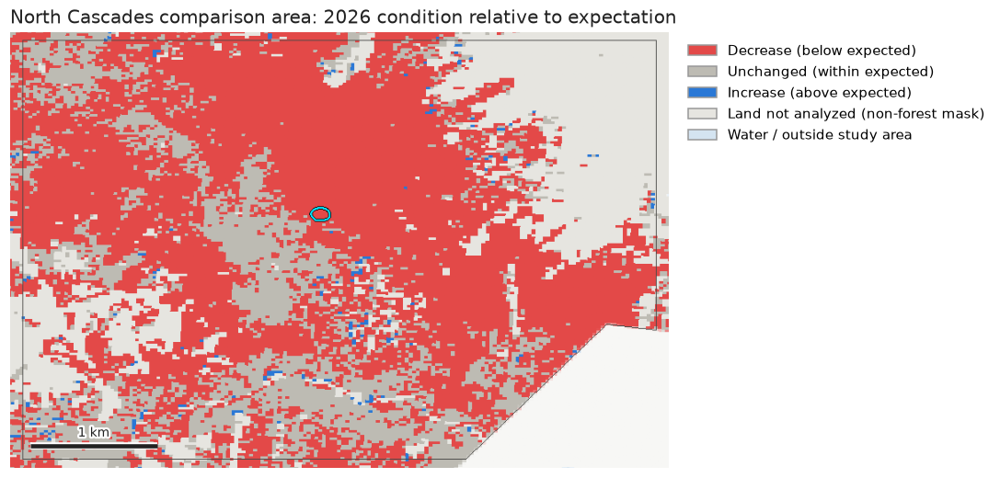

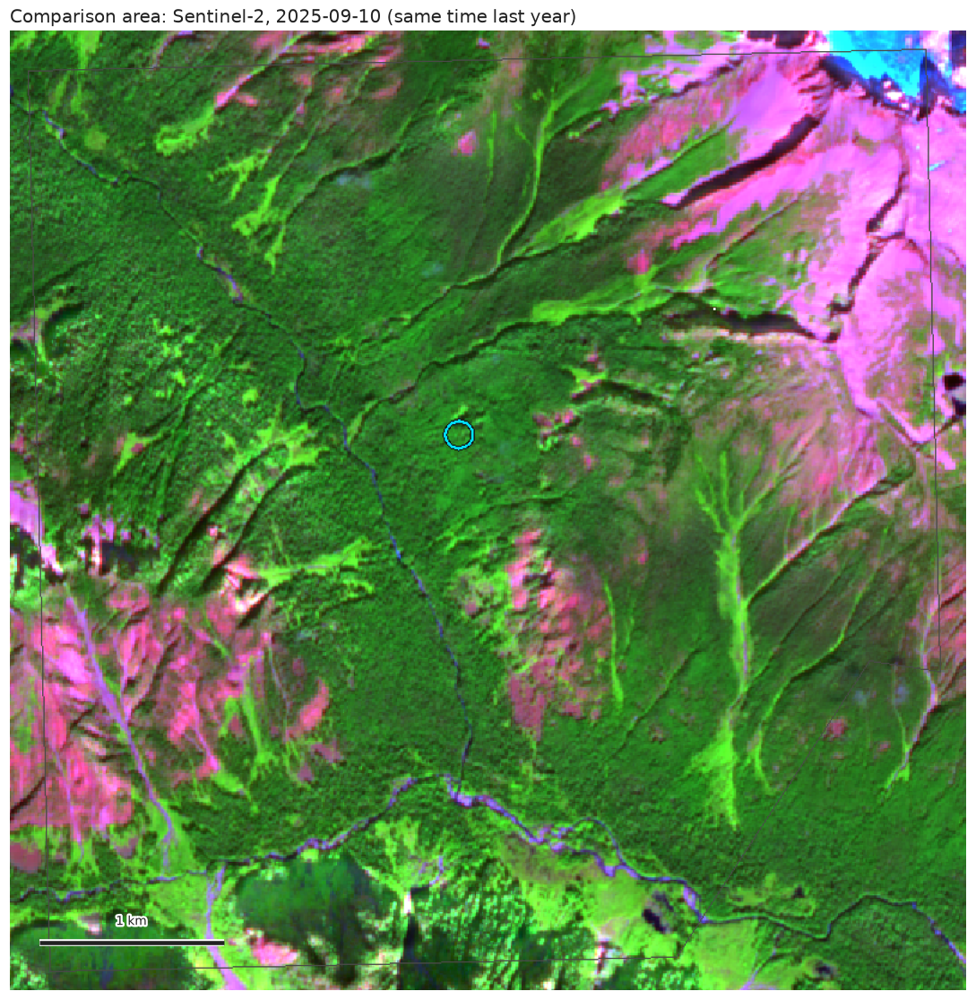

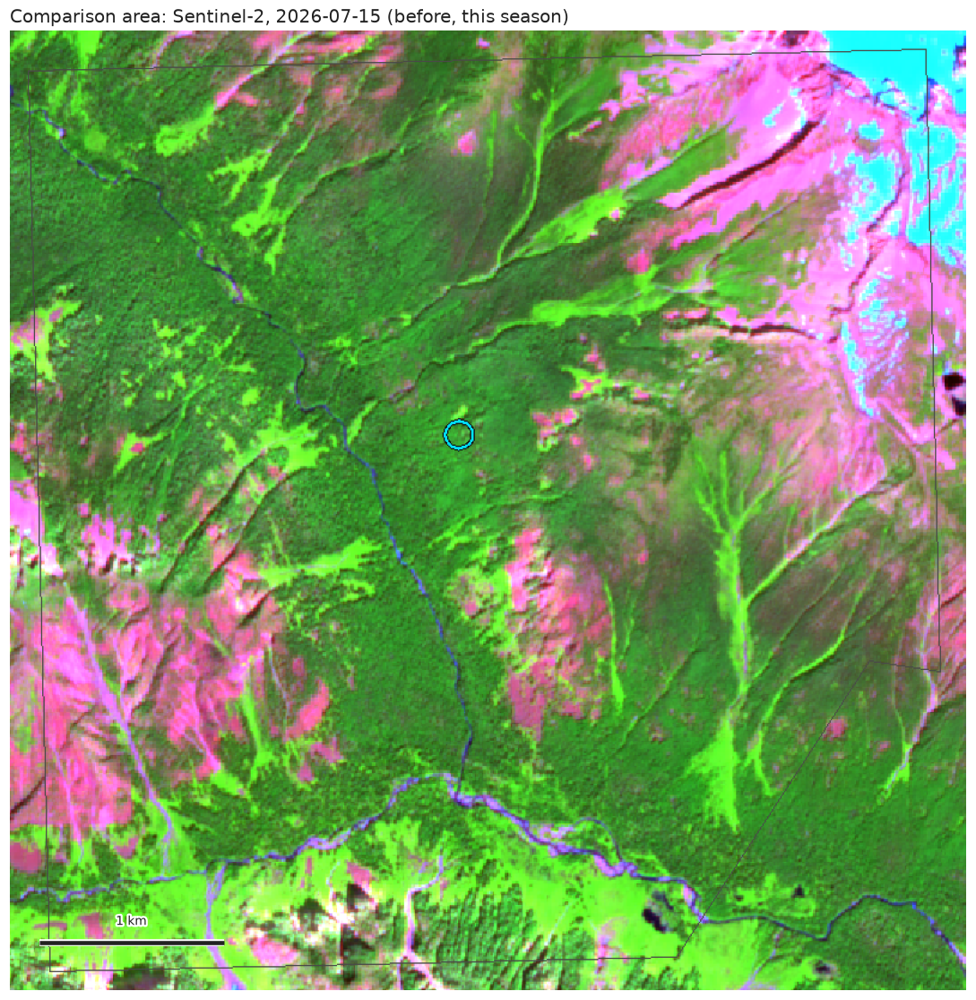

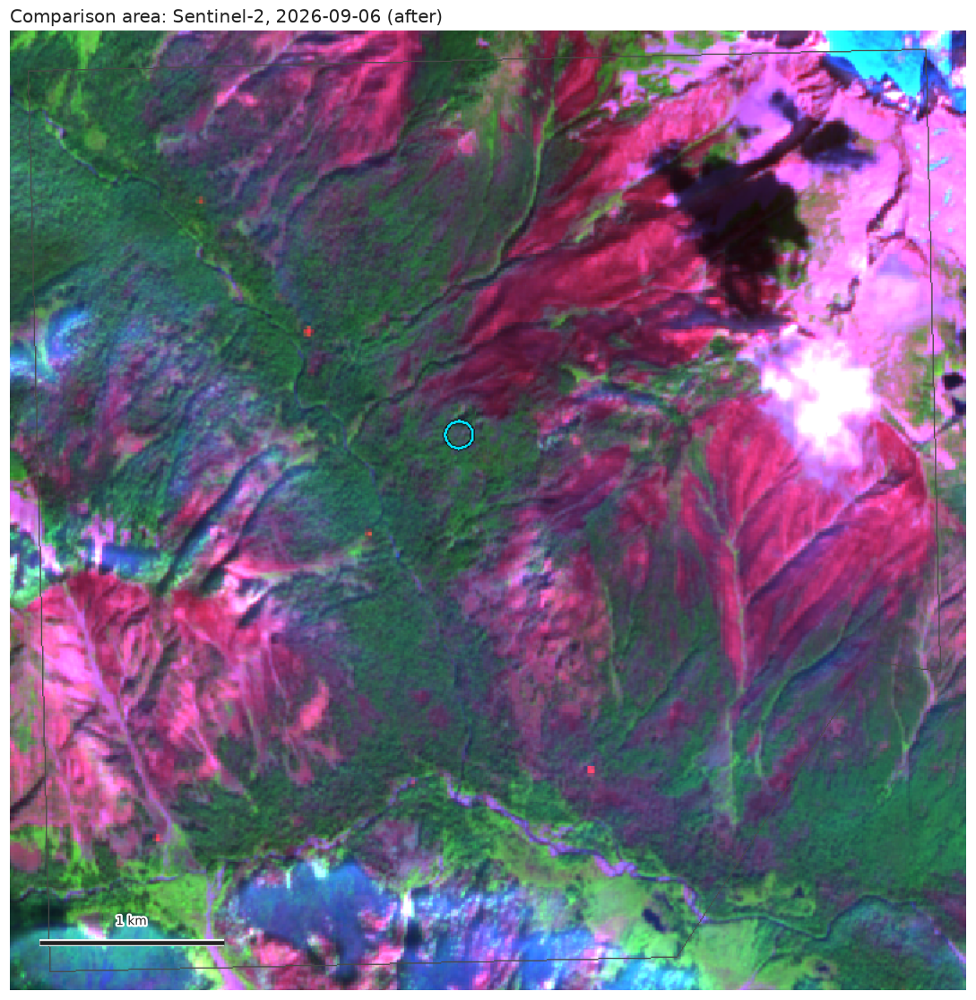

In [9]:
report.outcome_map(results, focus, focus_frame, focus_bbox, f"{FOCUS_NAME}: 2026 condition relative to expectation", token,
                   save_to=out_dir / "focus_condition.png", enlarge_changes=False, dimensions=800, marker=INSPECT_PIXEL)
report.scene_series(focus, focus_frame, focus_bbox, "Comparison area", token, [("same time last year", "20250910T190821_20250910T190823_T10UFV"), ("before, this season", "20260715T185921_20260715T190728_T10UFV"), ("after", "20260906T190921_20260906T191705_T10UFV")], out_dir / "comparison_area", marker=INSPECT_PIXEL);

### Inspecting one pixel

The pixel in the cyan ring on the maps above. **How it was chosen:** the pixel nearest the center of the largest decrease patch in the comparison area. It was chosen by that rule, not for how clean its curve looks.

- **Top:** each clear observation's NBR (dots) against the value expected from the baseline (dashed line). Each dot is colored by the outcome that observation supports.
- **Bottom:** BULC-D's probability of decrease as it updates, the 0.5 threshold, and the date it **first crossed** the threshold. Shading marks every period above the threshold.

"First detected" means the *first* crossing. The probability can drop back below the threshold afterward and cross again later; the shading shows whether it did.

This chart is the prototype of a planned interactive tool: **click a pixel on the map to see its history.** Set `INSPECT_PIXEL` (in the section 3 setup cell) to any (lon, lat) in the study area to inspect a different location.

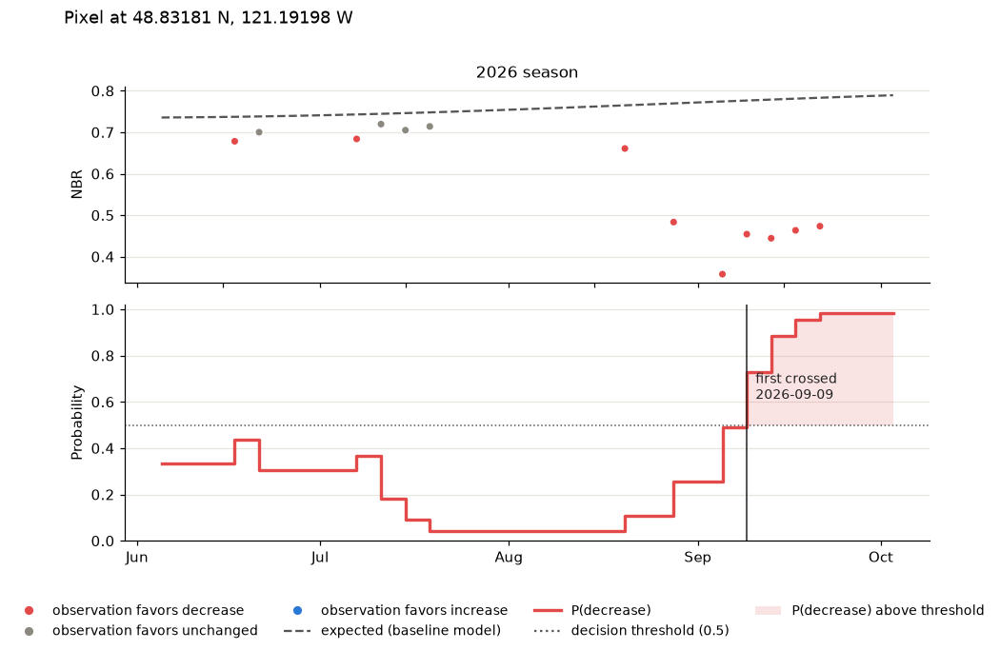

2026 season: first crossed the threshold on 2026-09-09 (13 clear observations)


In [10]:
histories = {}
for y in PIXEL_SEASONS:
    season_controls = MonitoringControls(**{**dataclasses.asdict(controls), "monitoring_year": y, **PIXEL_BASELINE})
    histories[f"{y} season"] = pixel.pixel_history(build(season_controls, **AREA.aoi), *INSPECT_PIXEL)
lon, lat = INSPECT_PIXEL
pixel.plot_pixel_history(histories, controls.decision_threshold, title=f"Pixel at {lat:.5f} N, {abs(lon):.5f} W",
                         save_to=out_dir / "pixel_history.png")
for label, rows in histories.items():
    crossed = pixel.first_crossing(rows, controls.decision_threshold)
    print(f"{label}: {'first crossed the threshold on ' + str(crossed) if crossed else 'never crossed the threshold'} "
          f"({sum(r['zscore'] is not None for r in rows)} clear observations)")

### What this run shows (prepared 2026-09-29)

- **Much more decrease is mapped than at Apostle Islands:** about 32% of analyzed forest (376 of 1,189 km²), plus 2.5% increase. About 833 km² (rock, ice, alpine) isn't analyzed.
- **It is widespread, heaviest in the north unit, and mostly detected later in the season.** Only about 1% of it was first detected in early June.
- **The comparison area shows a clearly visible change in clear single-date imagery,** starting between July 15 and 20, 2026. The inspected pixel there first crossed the threshold on September 9, after that change and with few clear observations because of haze.
- **Why so much decrease is flagged park-wide is unresolved and needs validation.** Possibilities include real 2026 change, haze or smoke, and how well the baseline model fits steep mountain forest. **Not field-checked;** no cause is assigned.

## 4. Understanding parameter behavior

**Holding everything else constant, what happens when one setting moves?** This is a one-at-a-time sensitivity check, meant to build understanding. It isn't a search for the "best" settings. Everything here uses **the North Cascades comparison area** at a fixed extent.

**Sensitivity, three ways.** Sensitivity scales every departure from normal before it's scored. Below default (0.5), only large departures count as strong evidence; above default (2.0), small ones do. Watch the flagged areas contract and expand.

Sensitivity 0.5 (below default): running BULC-D ... 

8 s
Sensitivity 1.0 (default): running BULC-D ... 

4 s
Sensitivity 2.0 (above default): running BULC-D ... 

8 s


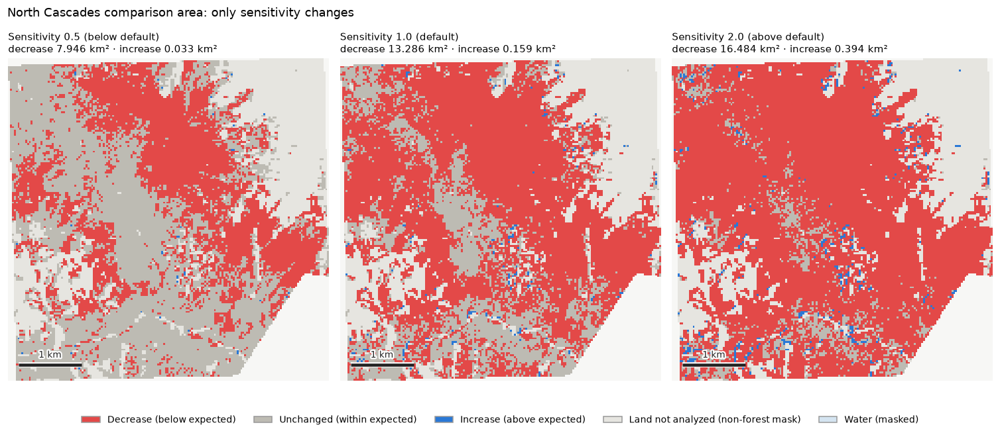

| Variant | Decrease (below expected) (km²) | Increase (above expected) (km²) | Unchanged (within expected) (km²) | Land not analyzed (non-forest mask) (km²) | What it tests |
|---|---:|---:|---:|---:|---|
| Sensitivity 0.5 (below default) | 7.946 | 0.033 | 10.763 | 4.963 | only large departures count strongly |
| Sensitivity 1.0 (default) | 13.286 | 0.159 | 5.297 | 4.963 | the section 2 settings |
| Sensitivity 2.0 (above default) | 16.484 | 0.394 | 1.864 | 4.963 | small departures count strongly |

In [11]:
sensitivity_variants = [
    compare.Variant("Sensitivity 0.5 (below default)", "only large departures count strongly", controls={"sensitivity": 0.5}),
    compare.Variant("Sensitivity 1.0 (default)", "the section 2 settings", controls={"sensitivity": 1.0}),
    compare.Variant("Sensitivity 2.0 (above default)", "small departures count strongly", controls={"sensitivity": 2.0}),
]
effects = compare.run_comparison(focus, controls, build, sensitivity_variants)
compare.show_comparison(effects, f"{FOCUS_NAME}: only sensitivity changes", save_to=out_dir / "sensitivity_maps.png")
display(Markdown(compare.comparison_table(effects)))

**Four parameters, one at a time.** Each panel moves one setting across a range while everything else stays at its default (dotted line), and shows how much decrease and increase is detected in the same area:

- **Sensitivity:** how strongly a given departure counts.
- **Decision threshold:** how sure BULC-D must be before flagging. It only re-reads the final probabilities.
- **Dampening:** how far a single observation can move the probabilities.
- **Posterior leveler:** how strongly the probabilities are pulled back toward even odds after each update (1 = off).

These charts show how each parameter behaves **in this example**. They aren't general rules and don't recommend settings; the other example notebooks show different responses for the same parameters.

*These comparison runs use their own 30 m grid, so default-setting totals can differ slightly (well under 1%) from section 3's precomputed numbers.*

Sensitivity = 0.5: running BULC-D ... 

4 s
Sensitivity = 0.75: running BULC-D ... 

7 s
Sensitivity = 1.0: running BULC-D ... 

49 s
Sensitivity = 1.5: running BULC-D ... 

4 s
Sensitivity = 2.0: running BULC-D ... 

...

3 s
Posterior leveler = 0.7: running BULC-D ... 

5 s
Posterior leveler = 0.8: running BULC-D ... 

4 s
Posterior leveler = 0.9: running BULC-D ... 

3 s
Posterior leveler = 0.95: running BULC-D ... 

4 s
Posterior leveler = 1.0: reusing an earlier run (differs only in threshold/masks)


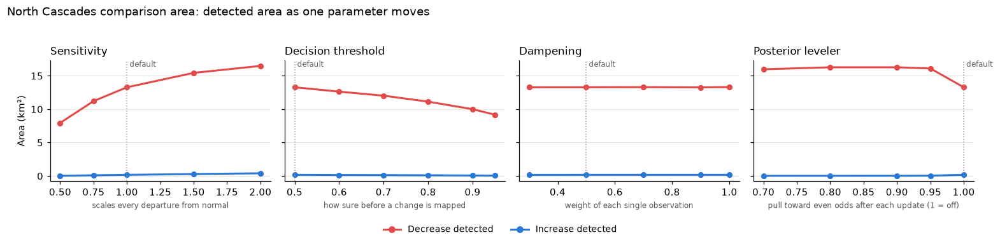

In [12]:
response = compare.parameter_response(focus, controls, build)
compare.plot_parameter_response(response, f"{FOCUS_NAME}: detected area as one parameter moves", save_to=out_dir / "parameter_response.png");

**What the charts show for the comparison area:**
- **Sensitivity produced the largest area response here:** decrease grew from 7.9 km² at 0.5 to 16.5 km² at 2.0.
- **The decision threshold mattered more here than on Devils Island** (13.3 → 9.2 km² at 0.95). The departure began mid-season, so by the end of September many pixels were still building evidence.
- **Dampening had little effect over the tested range here.**
- **The posterior leveler *increased* the flagged decrease** at every value below 1 (to about 16 km²), the opposite of Devils Island. It keeps probabilities from locking in on "unchanged" during the normal first half of the season, so pixels switch sooner once the departure begins.

## 5. Try it on your own area

This is how a user would point Early Detection at a new place. There are two ways to define the area:

- **Draw it:** set `TRY_OWN_AREA = True`, `AOI_MODE = "draw"` and a new `DRAWN_AOI_NAME`. Run the next cell, draw a polygon or rectangle on the map, then run the save cell. The area is saved and can be reused by name.
- **Use an Earth Engine FeatureCollection:** set `AOI_MODE = "asset"` and `CUSTOM_AOI_ASSET` to its asset ID.

Then run the remaining cells. The area's size is checked first: over 100 km² gets a warning, and over 1,000 km² is blocked unless `ALLOW_LARGE_AOI = True`. Your area runs live (a few minutes for a few km²). Drawing needs JupyterLab 4, Notebook 7 or VS Code.

In [13]:
TRY_OWN_AREA = False
AOI_MODE = "draw"                        # "draw" or "asset"
DRAWN_AOI_NAME = "my_area"               # saved as aois/<name>.geojson
CUSTOM_AOI_ASSET = "projects/your-project/assets/your_feature_collection"
ALLOW_LARGE_AOI = False
COMPARE_OWN_AREA = False                 # also run section 4's sensitivity maps on your area

if TRY_OWN_AREA and AOI_MODE == "draw":
    saved = drawing.aoi_path(DRAWN_AOI_NAME)
    detections = results.select("outcome")
    detections = detections.updateMask(detections.eq(outputs.DECREASE).Or(detections.eq(outputs.INCREASE)))
    overlay = drawing.ee_tile_layer(
        detections.visualize(min=0, max=2, palette=[render.OUTCOME_COLORS[0][1:], "ffffff", render.OUTCOME_COLORS[2][1:]]),
        "2026 detections")
    drawer = drawing.AOIDrawer(center=(48.68, -121.14), zoom=9, overlays=[overlay],
                               existing=drawing.load_polygon(DRAWN_AOI_NAME) if saved.exists() else None)
    display(drawer.map)
    print(f"Saved area {DRAWN_AOI_NAME!r}: {'found (yellow)' if saved.exists() else 'not saved yet - draw one, then run the next cell'}")
elif not TRY_OWN_AREA:
    print("Skipped (set TRY_OWN_AREA = True).")

Skipped (set TRY_OWN_AREA = True).


In [14]:
# Run after drawing, to save the drawn shape as DRAWN_AOI_NAME.
if TRY_OWN_AREA and AOI_MODE == "draw":
    path = drawer.save(DRAWN_AOI_NAME)
    if path:
        print(f"Saved {path}")
    elif drawing.aoi_path(DRAWN_AOI_NAME).exists():
        print(f"Nothing new drawn - using the saved {DRAWN_AOI_NAME!r}.")
    else:
        print("Nothing drawn yet: draw on the map above, then run this cell again.")

In [15]:
if TRY_OWN_AREA:
    own = drawing.study_area(DRAWN_AOI_NAME) if AOI_MODE == "draw" else outputs.from_asset(CUSTOM_AOI_ASSET)
    own_size = outputs.aoi_size_report(own)
    print(f"Area {own.name!r}: {own_size['area_km2']:,.1f} km² (bounding box {own_size['bbox_km2']:,.1f} km²)")
    if own_size["verdict"] == "slow":
        print(f"WARNING: larger than anything run live so far (~{outputs.TESTED_LIVE_KM2} km²); maps may be slow or time out.")
    elif own_size["verdict"] == "large" and not ALLOW_LARGE_AOI:
        raise RuntimeError(f"Area is {own_size['area_km2']:,.0f} km² (> {outputs.LARGE_AOI_KM2:,} km²). "
                           "Use a smaller area, or set ALLOW_LARGE_AOI = True to try anyway.")
    own_results = outputs.outcome_image(build(controls, **own.aoi), controls.decision_threshold).clip(own.geometry)
    own_frame, own_bbox = report.frame_for(own.geometry)
    own_out = OUT / f"{own.name}_{controls.monitoring_year}"
    report.outcome_map(own_results, own, own_frame, own_bbox, f"{own.name}: 2026 condition relative to expectation", token,
                       save_to=own_out / "condition.png", enlarge_changes=False)
    display(Markdown(report.area_table(own_results, own.geometry)[0]))
    report.reference_pair(own, own_frame, own_bbox, own.name, token, controls, own_out)
    if COMPARE_OWN_AREA:
        if own_size["verdict"] != "ok" and not ALLOW_LARGE_AOI:
            raise RuntimeError(f"Comparisons are limited to {outputs.TESTED_LIVE_KM2} km²; draw a smaller area.")
        own_effects = compare.run_comparison(own, controls, build, sensitivity_variants)
        compare.show_comparison(own_effects, f"{own.name}: sensitivity 0.5 | 1.0 | 2.0", save_to=own_out / "sensitivity.png")
        display(Markdown(compare.comparison_table(own_effects)))
else:
    print("Skipped (set TRY_OWN_AREA = True).")

Skipped (set TRY_OWN_AREA = True).


---
## Appendix: regenerating the precomputed results

For maintainers, only needed after changing settings. These start Earth Engine batch exports (about 40 minutes for the whole park); the notebook then loads the new results. Change the run names to keep the old ones.

In [16]:
RUN_EXPORT = False

if RUN_EXPORT:
    tasks = outputs.export_study_area(controls, build, AREA, PRECOMPUTED_FOLDER, PRECOMPUTED_RUN)
    print(outputs.wait_for(tasks))